# Pretrained Transformer Model (CamemBERT) for French Learner Error-Type Classification

This notebook trains a pretrained transformer model (CamemBERT) for sentence-level French learner error-type classification. The initial task formulation follows a **10-class taxonomy of learner errors**, including categories such as verb_form, tense_mood_aspect, lexical_choice, agreement, and others.

Following the baseline study, the main training setup uses **mixed training data** (synthetic single-error sentences combined with real learner sentences), as this configuration produced the strongest classical baseline on the real validation split (macro-F1 ≈ 0.269 on gold_val). The primary objective is therefore to surpass this baseline using a contextual model.

Model selection and hyperparameter tuning are performed exclusively on **gold_val**. The **gold_test** split remains fully untouched throughout development and is used exactly once for the final evaluation.

The notebook first explores a **two-stage adaptation strategy** (training on synthetic data first, followed by fine-tuning on real learner data). In addition, it conducts a **mixed-training experiment**. This comparison helps determine whether gradual domain adaptation improves robustness to multi-error sentences beyond simply mixing the data.

The best-performing model from these training strategies is then selected, and additional improvements—such as **weighted loss, maximum sequence length adjustments, and other targeted ablation studies**—are applied to assess whether performance can be further improved.

Finally, an **error analysis of the confusion matrix** reveals systematic confusions between several categories (notably agreement vs determiner_article and lexical_choice vs preposition vs word_order). Based on this analysis, the taxonomy is refined through linguistically motivated label merges, resulting in a **final 7-class classification setup** used for the final evaluation.

CamemBERT is pretrained on large-scale French corpora and produces contextualized representations in which token embeddings depend on their surrounding context. This property is particularly beneficial for error categories that require sentence-level syntactic and semantic cues, which are difficult for TF-IDF-based models to capture.




In [ ]:
#Setup and import

import pandas as pd
import numpy as np
import random
import torch

from pathlib import Path
from datasets import (
    Dataset,
    DatasetDict,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import numpy as np
import torch

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns





In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
#load the clean data already preprocessed

BASE_DIR = Path("/content/drive/MyDrive/Final_Project/data/final_splits_clean")

train_syn  = pd.read_csv(BASE_DIR / "train_syn_clean.csv")
train_real = pd.read_csv(BASE_DIR / "train_real_clean.csv")
gold_val   = pd.read_csv(BASE_DIR / "gold_val_clean.csv")
gold_test = pd.read_csv (BASE_DIR/ "gold_test_clean.csv")

#labels

LABELS = [
    "verb_form",
    "tense_mood_aspect",
    "lexical_choice",
    "agreement",
    "word_order",
    "pronoun_clitic",
    "preposition",
    "determiner_article",
    "negation",
    "spelling_orthography"
]

#Experiment 1 — Two-Stage Training: SYN → REAL Adaptation

This experiment investigates a two-stage training strategy for 10-class sentence-level French learner error classification using CamemBERT.

This setup separates learning into two phases:

* Phase 1: Train exclusively on synthetic data.

* Phase 2: Continue training (fine-tuning) on real learner data with a smaller learning rate.

The objective is to test whether structured adaptation — first learning general patterns from large synthetic data, then specializing on real learner distribution — improves generalization on gold validation data.

Evaluation is performed only on gold_val, keeping gold_test untouched.


In [ ]:
#create the sets

train_df = train_syn.copy()
real_df = train_real.copy()
val_df   = gold_val.copy()
test_df  = gold_test.copy()


#label mapping

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

print("Label to ID mapping:")
print(label2id)


for df in [train_df, real_df, val_df, test_df]:
    df["label_id"] = df["label"].map(label2id)
print(train_df[["label", "label_id"]].head(10))
print(train_df["label_id"].nunique(), real_df["label_id"].nunique(), val_df["label_id"].nunique(), test_df["label_id"].nunique())


#convert pandas into HF
hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "real_train": Dataset.from_pandas(real_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})



#rename label_id to "labels"

hf_ds = hf_ds.rename_column("label_id", "labels")

hf_ds



Label to ID mapping:
{'verb_form': 0, 'tense_mood_aspect': 1, 'lexical_choice': 2, 'agreement': 3, 'word_order': 4, 'pronoun_clitic': 5, 'preposition': 6, 'determiner_article': 7, 'negation': 8, 'spelling_orthography': 9}
       label  label_id
0  verb_form         0
1  verb_form         0
2  verb_form         0
3  verb_form         0
4  verb_form         0
5  verb_form         0
6  verb_form         0
7  verb_form         0
8  verb_form         0
9  verb_form         0
10 10 10 10


DatasetDict({
    train: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 14341
    })
    real_train: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 398
    })
    validation: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 183
    })
    test: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 276
    })
})

In [ ]:
print ("Train shape:", hf_ds["train"].num_rows)
print ("Real Train shape:", hf_ds["real_train"].num_rows)
print ("Validation shape:", hf_ds["validation"].num_rows)
print ("Test shape:",hf_ds["test"].num_rows)


Train shape: 14341
Real Train shape: 398
Validation shape: 183
Test shape: 276


In [ ]:
#tokenization setup

checkpoint = "camembert-base"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)


def tokenize(batch):
  return tokenizer(batch["learner_sentence"], truncation=True, max_length = 128)

tokenized_ds_syn = hf_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_ds_syn.set_format("torch", columns=["input_ids","attention_mask","labels"])

#metric function

def compute_metrics (eval_pred):
  logits, labels = eval_pred
  pred = np.argmax(logits, axis=1)
  accuracy = accuracy_score(y_true=labels, y_pred=pred)
  macro_f1 = f1_score(y_true=labels, y_pred=pred, average="macro")
  return {"accuracy": accuracy, "macro_f1": macro_f1}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

...

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/14341 [00:00<?, ? examples/s]

Map:   0%|          | 0/398 [00:00<?, ? examples/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

#Phase 1 — Training on Synthetic Data Only

In Phase 1, the model is trained solely on the synthetic dataset using the following hyperparameters:

1.   Learning rate: 2e-5
2.   Epochs: 3
3.   Early stopping enabled
4.   Same preprocessing and tokenization
5.   Same evaluation protocol

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.440450,2.242213,0.344262,0.376233
2,0.138271,2.977858,0.349727,0.379327
3,0.065030,3.263769,0.333333,0.362660


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

                      precision    recall  f1-score   support

           verb_form       0.69      0.28      0.40        32
   tense_mood_aspect       0.31      0.92      0.46        13
      lexical_choice       0.50      0.06      0.11        31
           agreement       0.62      0.43      0.51        23
          word_order       0.25      0.20      0.22        10
      pronoun_clitic       0.89      0.80      0.84        10
         preposition       0.33      0.05      0.09        20
  determiner_article       0.09      0.31      0.14        13
            negation       0.80      0.67      0.73        12
spelling_orthography       0.22      0.42      0.29        19

            accuracy                           0.35       183
           macro avg       0.47      0.41      0.38       183
        weighted avg       0.49      0.35      0.34       183

[[ 9  3  0  2  1  1  0  8  0  8]
 [ 1 12  0  0  0  0  0  0  0  0]
 [ 0  9  2  2  1  0  1 11  0  5]
 [ 2  1  0 10  0  0  0  5  0  

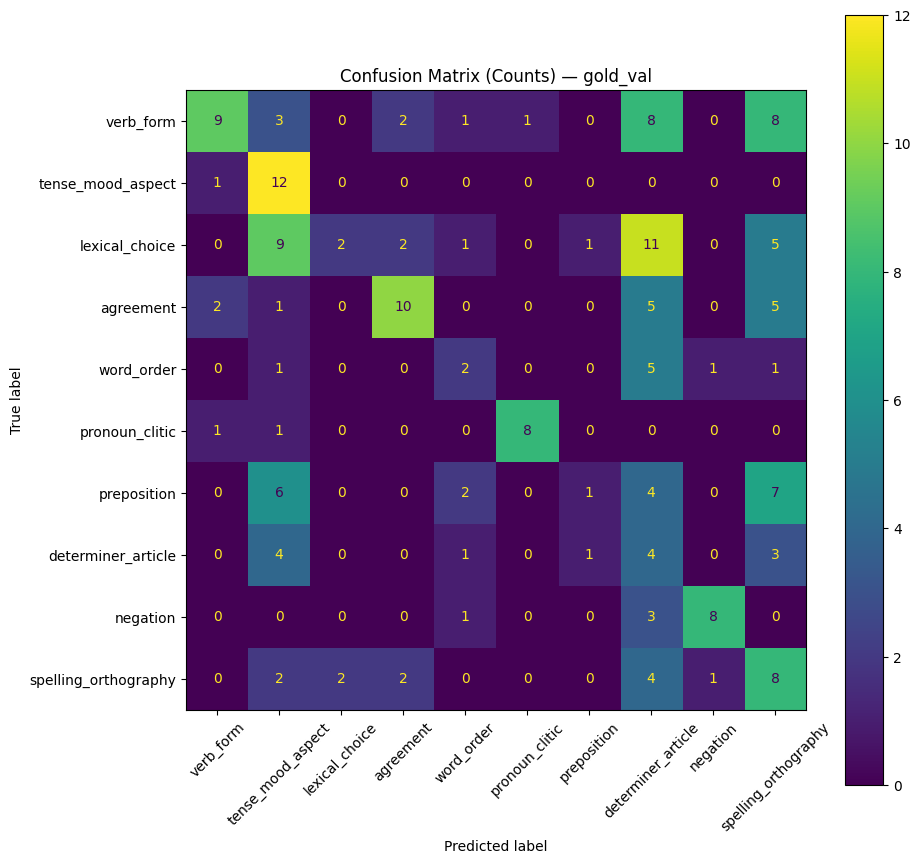

[[0.28125    0.09375    0.         0.0625     0.03125    0.03125
  0.         0.25       0.         0.25      ]
 [0.07692308 0.92307692 0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.29032258 0.06451613 0.06451613 0.03225806 0.
  0.03225806 0.35483871 0.         0.16129032]
 [0.08695652 0.04347826 0.         0.43478261 0.         0.
  0.         0.2173913  0.         0.2173913 ]
 [0.         0.1        0.         0.         0.2        0.
  0.         0.5        0.1        0.1       ]
 [0.1        0.1        0.         0.         0.         0.8
  0.         0.         0.         0.        ]
 [0.         0.3        0.         0.         0.1        0.
  0.05       0.2        0.         0.35      ]
 [0.         0.30769231 0.         0.         0.07692308 0.
  0.07692308 0.30769231 0.         0.23076923]
 [0.         0.         0.         0.         0.08333333 0.
  0.         0.25       0.66666667 0.        ]
 [0.         0.10526316 0.10526

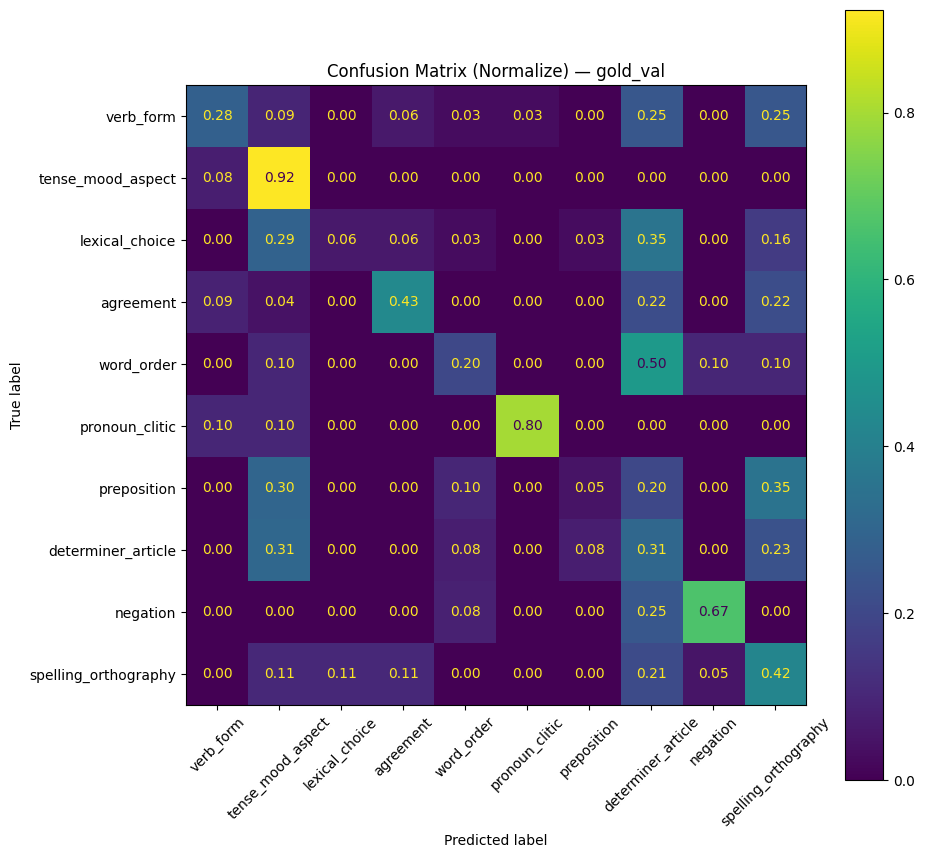

In [ ]:

training_args_A1 = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/camembert_synonly",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    seed=42,
    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_A1 = Trainer(
    model=model,
    args=training_args_A1,
    train_dataset=tokenized_ds_syn["train"],
    eval_dataset=tokenized_ds_syn["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.0
)]
)


trainer_A1.train()

trainer_A1.save_model("/content/drive/MyDrive/Final_Project/models/camembert_synonly_best")
tokenizer.save_pretrained("/content/drive/MyDrive/Final_Project/models/camembert_synonly_best")

#classification report + confusion matrix
preds = trainer_A1.predict(tokenized_ds_syn ["validation"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=LABELS))



#Confusion matrix (counts)
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Confusion matrix plot (counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (Counts) — gold_val")
plt.show()
#Row-normalized confusion matrix

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Confusion Matrix (Normalize) — gold_val")
plt.show()


# Result phase 1 (gold_val)

Best Macro-F1: 0.379
Best Accuracy: 0.349

Some classes (e.g., tense_mood_aspect, negation) remain strong.

Minority and syntactically subtle classes (word_order, preposition) remain difficult.

Overfitting signs appear (training loss decreases strongly while validation loss increases).

This suggests that synthetic data alone does not fully capture the distributional complexity of real learner errors.

#Phase 2 — Fine-Tuning on Real Learner Data


In Phase 2, training resumes from the best Phase 1 checkpoint and continues on real learner data only.

Adjustments:

1.  Learning rate reduced to 5e-6
2.  Epochs reduced to 2
The goal is to adapt gently without catastrophic forgetting

In [ ]:

# Load the model from your A1 best checkpoint
A1_BEST_DIR = "/content/drive/MyDrive/Final_Project/models/camembert_synonly_best"

model_A2 = AutoModelForSequenceClassification.from_pretrained(
    A1_BEST_DIR,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)

# Tokenize is already done in tokenized_ds_syn because it came from hf_ds


# Use more conservative training args for Phase 2
training_args_A2 = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/camembert_A2_syn_to_real",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    num_train_epochs=2,          # fewer epochs
    learning_rate=5e-6,          # smaller LR than A1
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    weight_decay=0.01,
    max_grad_norm=1.0,
    seed=42,

    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_A2 = Trainer(
    model=model_A2,
    args=training_args_A2,
    train_dataset=tokenized_ds_syn["real_train"],     # REAL fine-tune
    eval_dataset=tokenized_ds_syn["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_A2.train()

# Save A2 best model
trainer_A2.save_model("/content/drive/MyDrive/Final_Project/models/camembert_A2_best")
tokenizer.save_pretrained("/content/drive/MyDrive/Final_Project/models/camembert_A2_best")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,2.603215,0.393443,0.432146
2,No log,2.530652,0.387978,0.427454


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Final_Project/models/camembert_A2_best/tokenizer_config.json',
 '/content/drive/MyDrive/Final_Project/models/camembert_A2_best/tokenizer.json')

# Results Pahse 2 (gold_val)

Macro-F1: 0.432
Accuracy: 0.393

The results show that there is a light improvement over Phase 1 . Therefore, there is no substantial gain from real-data adaptation.The absence of large improvement suggests:

*   The real dataset may be too small for effective specialization.
*   Mixed training may already perform implicit adaptation.
*   Synthetic and real distributions may differ more than expected.

#Experiment 2: Mixed Synthetic + Real Training

This experiment evaluates a pretrained transformer model (CamemBERT) on the task of 10-class sentence-level French learner error type classification, using the strongest training configuration identified in the baseline experiments. In the classical setup, a TF-IDF + Logistic Regression model trained on the concatenation of synthetic and real learner data yielded the best validation performance (macro-F1 ≈ 0.269 on gold_val).

Following this observation, Experiment 2 trains CamemBERT on the same combined training set (synthetic mono-error data and real multi-error learner data), with the goal of assessing how much contextualized representations improve performance over surface n-gram features. Model selection and early stopping are performed exclusively on the gold_val split, while gold_test remains fully untouched.

CamemBERT is pretrained on large-scale French corpora and produces contextualized token representations, allowing the model to encode syntactic relations, agreement patterns, and semantic dependencies that TF-IDF models cannot represent explicitly. This experiment therefore serves as a direct comparison between classical feature-based methods and modern contextual language models under identical data conditions.

In [ ]:
#create the sets

train_df = pd.concat([train_syn, train_real], axis=0, ignore_index=True)
val_df   = gold_val.copy()
test_df  = gold_test.copy()

In [ ]:
#train_df size, val_df size, test_df size

print("Train_df size :", train_df.shape)
print("Val_df size :", val_df.shape)
print("Test_df size :", test_df.shape)

# label counts

print(f"==== train_df label counts ====:")
print (train_df["label"].value_counts())
print ("..............................")

print(f"==== val_df label counts ====:")
print(val_df["label"].value_counts())
print ("..............................")


print(f"==== test_df label counts ====:")
print(test_df["label"].value_counts())
print ("..............................")

Train_df size : (14739, 2)
Val_df size : (183, 2)
Test_df size : (276, 2)
==== train_df label counts ====:
label
verb_form               1911
tense_mood_aspect       1697
agreement               1648
lexical_choice          1645
word_order              1502
pronoun_clitic          1459
preposition             1432
negation                1246
spelling_orthography    1102
determiner_article      1097
Name: count, dtype: int64
..............................
==== val_df label counts ====:
label
verb_form               32
lexical_choice          31
agreement               23
preposition             20
spelling_orthography    19
determiner_article      13
tense_mood_aspect       13
negation                12
word_order              10
pronoun_clitic          10
Name: count, dtype: int64
..............................
==== test_df label counts ====:
label
verb_form               47
preposition             41
agreement               37
lexical_choice          32
spelling_orthography    29
det

In [ ]:
train_df.columns

Index(['learner_sentence', 'label'], dtype='object')

In [ ]:
#label mapping

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

print("Label to ID mapping:")
print(label2id)


for df in [train_df, val_df, test_df]:
    df["label_id"] = df["label"].map(label2id)
print(train_df[["label", "label_id"]].head(10))
print(train_df["label_id"].nunique(), val_df["label_id"].nunique(), test_df["label_id"].nunique())



Label to ID mapping:
{'verb_form': 0, 'tense_mood_aspect': 1, 'lexical_choice': 2, 'agreement': 3, 'word_order': 4, 'pronoun_clitic': 5, 'preposition': 6, 'determiner_article': 7, 'negation': 8, 'spelling_orthography': 9}
       label  label_id
0  verb_form         0
1  verb_form         0
2  verb_form         0
3  verb_form         0
4  verb_form         0
5  verb_form         0
6  verb_form         0
7  verb_form         0
8  verb_form         0
9  verb_form         0
10 10 10


In [ ]:
#convert pandas into HF
hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})



#rename label_id to "labels"

hf_ds = hf_ds.rename_column("label_id", "labels")

hf_ds


DatasetDict({
    train: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 14739
    })
    validation: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 183
    })
    test: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 276
    })
})

In [ ]:
#tokenization setup

checkpoint = "camembert-base"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)


def tokenize(batch):
  return tokenizer(batch["learner_sentence"], truncation=True, max_length = 128)

tokenized_dataset = hf_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_dataset.set_format("torch", columns=["input_ids","attention_mask","labels"])

#metric function

def compute_metrics (eval_pred):
  logits, labels = eval_pred
  pred = np.argmax(logits, axis=1)
  accuracy = accuracy_score(y_true=labels, y_pred=pred)
  macro_f1 = f1_score(y_true=labels, y_pred=pred, average="macro")
  return {"accuracy": accuracy, "macro_f1": macro_f1}




training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/camembert_run1",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    seed=42,
    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.0
)]
)


trainer.train()
trainer.evaluate()


trainer.save_model ("/content/drive/MyDrive/Final_Project/models/camembert_best")
tokenizer.save_pretrained("/content/drive/MyDrive/Final_Project/models/camembert_best")

#classification report + confusion matrix
preds = trainer.predict(tokenized_dataset["validation"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=LABELS))



#Confusion matrix (counts)
cm = confusion_matrix(y_true, y_pred)
print(cm)


#Row-normalized confusion matrix

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/14739 [00:00<?, ? examples/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

                      precision    recall  f1-score   support

           verb_form       0.67      0.31      0.43        32
   tense_mood_aspect       0.55      0.85      0.67        13
      lexical_choice       0.80      0.13      0.22        31
           agreement       0.53      0.43      0.48        23
          word_order       0.31      0.50      0.38        10
      pronoun_clitic       0.82      0.90      0.86        10
         preposition       0.60      0.30      0.40        20
  determiner_article       0.14      0.46      0.22        13
            negation       0.83      0.83      0.83        12
spelling_orthography       0.27      0.47      0.35        19

            accuracy                           0.44       183
           macro avg       0.55      0.52      0.48       183
        weighted avg       0.58      0.44      0.44       183

[[10  3  0  4  1  2  0  8  0  4]
 [ 1 11  0  0  1  0  0  0  0  0]
 [ 0  0  4  2  3  0  3 12  0  7]
 [ 3  0  0 10  0  0  0  7  0  

#Results experiment 2

Training CamemBERT on the mixed synthetic + real dataset yields a substantial improvement over the strongest TF-IDF baseline, and also experiment 1. On gold_val, the model now reaches a macro-F1 of ≈ 0.49 and an accuracy of 0.46, representing an absolute gain of approximately +22 macro-F1 points compared to the classical baseline (≈ 0.27).

Performance is particularly strong for morpho-syntactic categories with clear contextual signals, such as negation, pronoun_clitic, and tense_mood_aspect, where F1 exceeds 0.69–0.85. More ambiguous or overlapping categories—especially word_order, preposition, determiner_article, lexical_choice—remain challenging. Error analysis shows these categories are frequently confused, reflecting both their linguistic similarity and the presence of multiple error types within the same sentence.

Overall, Experiment 2 demonstrates that contextualized transformer representations significantly improve learner error classification. While the model achieves strong gains over classical baselines, the intrinsic difficulty of fine-grained, multi-class error labeling in realistic learner data keeps macro-F1 below 60%, which is consistent with trends observed in the literature.



## Experience 3+: Mixed Training + Improvements

In the previous experiments, the **concatenated mixed training setup (synthetic + real learner data)** produced the best performance among the transformer configurations, reaching approximately **macro-F1 ≈ 0.49** and **accuracy ≈ 0.46** on the validation set.

Because this configuration yielded the strongest results, it is used as the **reference model** for further improvements.

In this section, several targeted **ablation experiments** are conducted to determine whether performance can be further improved. Each run introduces a single modification to the baseline mixed-training setup:

* **Run 1:** weighted loss to mitigate class imbalance
* **Run 2:** lower learning rate (**1e-5**) to test a more stable fine-tuning regime
* **Run 3:** label smoothing to reduce overconfidence in predictions
* **Run 4:** oversampling within the mixed training set to balance rare error categories

The objective of these experiments is to assess whether these training adjustments can **increase macro-F1**, which is the primary metric for this multi-class classification task.



#Run 1: weighted loss to mitigate class imbalance

In [ ]:

#Build MIXED datasets

train_df = pd.concat([train_syn, train_real], axis=0, ignore_index=True)
val_df  = gold_val.copy()
test_df = gold_test.copy()

print("Train_df size :", train_df.shape)
print("Val_df size   :", val_df.shape)
print("Test_df size  :", test_df.shape)

print("==== train_df label counts ====")
print(train_df["label"].value_counts())
print("==== val_df label counts ====")
print(val_df["label"].value_counts())
print("==== test_df label counts ====")
print(test_df["label"].value_counts())

# label mapping
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

for df in [train_df, val_df, test_df]:
    df["label_id"] = df["label"].map(label2id)

print(train_df[["label", "label_id"]].head(10))
print(train_df["label_id"].nunique(), val_df["label_id"].nunique(), test_df["label_id"].nunique())

# HF datasets
hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})
hf_ds = hf_ds.rename_column("label_id", "labels")


# Tokenization + model

checkpoint = "camembert-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)

def tokenize(batch):
    return tokenizer(batch["learner_sentence"], truncation=True, max_length=128)

tokenized_dataset = hf_ds.map(tokenize, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


# Metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=1)
    accuracy = accuracy_score(y_true=labels, y_pred=pred)
    macro_f1 = f1_score(y_true=labels, y_pred=pred, average="macro")
    return {"accuracy": accuracy, "macro_f1": macro_f1}



# class weights

y_train = train_df["label_id"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(LABELS)),
    y=y_train
)

# torch tensor for loss
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)



#  Custom Trainer with weighted loss

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Move weights to the same device as logits
        weights = self.class_weights.to(logits.device)

        loss_fct = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


# TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/camembert_run1_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    seed=42,

    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,
        early_stopping_threshold=0.0
    )]
)

trainer.train()
eval_metrics = trainer.evaluate()
print("Eval metrics:", eval_metrics)

# Save best
trainer.save_model("/content/drive/MyDrive/Final_Project/models/camembert_best_weighted")
tokenizer.save_pretrained("/content/drive/MyDrive/Final_Project/models/camembert_best_weighted")



#  Validation report/confusion matrix

preds = trainer.predict(tokenized_dataset["validation"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=LABELS))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (counts):")
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print("Confusion matrix (row-normalized):")
print(cm_norm)


Train_df size : (14739, 2)
Val_df size   : (183, 2)
Test_df size  : (276, 2)
==== train_df label counts ====
label
verb_form               1911
tense_mood_aspect       1697
agreement               1648
lexical_choice          1645
word_order              1502
pronoun_clitic          1459
preposition             1432
negation                1246
spelling_orthography    1102
determiner_article      1097
Name: count, dtype: int64
==== val_df label counts ====
label
verb_form               32
lexical_choice          31
agreement               23
preposition             20
spelling_orthography    19
determiner_article      13
tense_mood_aspect       13
negation                12
word_order              10
pronoun_clitic          10
Name: count, dtype: int64
==== test_df label counts ====
label
verb_form               47
preposition             41
agreement               37
lexical_choice          32
spelling_orthography    29
determiner_article      26
tense_mood_aspect       18
pronoun_cli

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Eval metrics: {'eval_loss': 2.4986181259155273, 'eval_accuracy': 0.4262295081967213, 'eval_macro_f1': 0.45433097263857514, 'eval_runtime': 0.3084, 'eval_samples_per_second': 593.303, 'eval_steps_per_second': 19.453, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

                      precision    recall  f1-score   support

           verb_form       0.60      0.38      0.46        32
   tense_mood_aspect       0.50      0.85      0.63        13
      lexical_choice       0.46      0.19      0.27        31
           agreement       0.60      0.52      0.56        23
          word_order       0.33      0.30      0.32        10
      pronoun_clitic       0.69      0.90      0.78        10
         preposition       0.33      0.15      0.21        20
  determiner_article       0.13      0.31      0.18        13
            negation       0.83      0.83      0.83        12
spelling_orthography       0.24      0.42      0.30        19

            accuracy                           0.43       183
           macro avg       0.47      0.48      0.45       183
        weighted avg       0.47      0.43      0.42       183

Confusion matrix (counts):
[[12  4  0  2  1  2  1  6  0  4]
 [ 1 11  0  0  0  1  0  0  0  0]
 [ 1  2  6  1  1  0  3  9  0  8]
 [ 

#Result run 1 : weighted loss
Weighted loss was tested on the mixed SYN+REAL training setup by using class-weighted cross-entropy (weights computed from the mixed training label distribution). The weighted-loss model underperformed the unweighted baseline: macro-F1 dropped from ~0.489 to ~0.454 and accuracy from ~0.464 to ~0.426 on the validation set. Per-label results and the confusion matrix did not show consistent improvements for minority classes; instead, several categories became more confused (notably preposition/lexical_choice/word_order). This suggests the mixed training regime already handles imbalance reasonably well, and explicit class weighting reduces overall generalization here. We therefore do not retain weighted loss and move on to other ablations.


#Run 2: lower learning rate (1e-5) to test a more stable fine-tuning regime

In [ ]:
# keep everything exactly the same

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)


training_args_1e5 = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/camembert_run_lr1e5",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    num_train_epochs=3,
    learning_rate=1e-5,  # <-- ONLY real change
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    seed=42,

    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_lr1e5 = Trainer(
    model=model,
    args=training_args_1e5,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,
        early_stopping_threshold=0.0
    )]
)


trainer_lr1e5.train()
eval_metrics = trainer_lr1e5.evaluate()
print("Eval metrics:", eval_metrics)

trainer_lr1e5.save_model("/content/drive/MyDrive/Final_Project/models/camembert_best_lr1e5")
tokenizer.save_pretrained("/content/drive/MyDrive/Final_Project/models/camembert_best_lr1e5")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated 

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.040182,1.928771,0.398907,0.395472
2,0.572008,1.967763,0.387978,0.401828
3,0.412921,1.980726,0.409836,0.429675


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Eval metrics: {'eval_loss': 1.980725884437561, 'eval_accuracy': 0.4098360655737705, 'eval_macro_f1': 0.4296751745383964, 'eval_runtime': 0.2839, 'eval_samples_per_second': 644.702, 'eval_steps_per_second': 21.138, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Final_Project/models/camembert_best_lr1e5/tokenizer_config.json',
 '/content/drive/MyDrive/Final_Project/models/camembert_best_lr1e5/tokenizer.json')

#Result run 2: LR 1e-5

Lowering the learning rate from 2e-5 to 1e-5 in the mixed SYN+REAL setup reduced validation performance (macro-F1 ~0.489 → ~0.430; accuracy ~0.464 → ~0.410). This suggests the more conservative LR underfits within the fixed 3-epoch budget. We therefore keep LR=2e-5 and explore other options.

In [ ]:
lengths = train_df["learner_sentence"].apply(lambda x: len(tokenizer.tokenize(x)))
print(lengths.describe())


count    14739.000000
mean        27.080263
std         11.446359
min          4.000000
25%         18.000000
50%         25.000000
75%         35.000000
max         89.000000
Name: learner_sentence, dtype: float64


#Run 3: label smoothing to reduce overconfidence in predictions

In [ ]:
# keep everything exactly the same

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)


training_args_ls = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/camembert_run_ls",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    label_smoothing_factor=0.1,


    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    seed=42,

    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer_ls = Trainer(
    model=model,
    args=training_args_ls,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,
        early_stopping_threshold=0.0
    )]
)


trainer_ls.train()
eval_metrics = trainer_ls.evaluate()
print("Eval metrics:", eval_metrics)

trainer_ls.save_model("/content/drive/MyDrive/Final_Project/models/camembert_best_ls")
tokenizer.save_pretrained("/content/drive/MyDrive/Final_Project/models/camembert_best_ls")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated 

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.807978,2.060785,0.431694,0.434718
2,0.612135,2.362643,0.398907,0.423306
3,0.557324,2.305587,0.426230,0.443988


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Eval metrics: {'eval_loss': 2.3055872917175293, 'eval_accuracy': 0.4262295081967213, 'eval_macro_f1': 0.4439881990809802, 'eval_runtime': 0.2, 'eval_samples_per_second': 915.194, 'eval_steps_per_second': 30.006, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Final_Project/models/camembert_best_ls/tokenizer_config.json',
 '/content/drive/MyDrive/Final_Project/models/camembert_best_ls/tokenizer.json')

##Result run 3: label smoothing (0.1)

Label smoothing was tested as a regularization technique to reduce overconfident predictions in a 10-way setting with overlapping labels. All hyperparameters were kept identical to the MIXED baseline (LR=2e-5, max_length=128, 3 epochs, early stopping); only label_smoothing_factor=0.1 was added. Results showed a decrease in validation performance (macro-F1 ~0.489 → ~0.444; accuracy ~0.464 → ~0.432), so label smoothing was not retained.

#Run 4: oversampling within the mixed training set to balance rare error categories

In the mixed training setup (SYN + REAL), the synthetic data largely dominates the training distribution (≈14k synthetic vs ≈400 real examples). This may cause the model to prioritize synthetic patterns and under-adapt to real learner errors. To rebalance this influence without changing the loss function or optimization setup, we test simple **data-level oversampling** of the REAL subset.

So we duplicate the REAL training set *k* times (here, k = 10) before concatenating it with the SYN data. All other settings remain identical to the baseline:

* Same model (CamemBERT-base)
* Same max_length (128)
* Same learning rate (2e-5)
* Same epochs (3)
* Same early stopping
* Same evaluation protocol

This ensures that any change in performance can be attributed solely to the increased weight of REAL examples in the training distribution.


The aim of this experience is to evaluate whether giving more prominence to real annotated learner data improves macro-F1 and reduces confusion between closely related error categories.


In [ ]:


k = 10

# Build the sets
train_df = pd.concat(
    [train_syn, pd.concat([train_real] * k, axis=0, ignore_index=True)],
    axis=0,
    ignore_index=True
)

val_df  = gold_val.copy()
test_df = gold_test.copy()

print("Train_df size :", train_df.shape)
print("Val_df size   :", val_df.shape)
print("Test_df size  :", test_df.shape)

print("==== train_df label counts ====")
print(train_df["label"].value_counts())
print("..............................")
print("==== val_df label counts ====")
print(val_df["label"].value_counts())
print("..............................")
print("==== test_df label counts ====")
print(test_df["label"].value_counts())
print("..............................")

# Label mapping (same as your original)
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

print("Label to ID mapping:")
print(label2id)

for df in [train_df, val_df, test_df]:
    df["label_id"] = df["label"].map(label2id)

print(train_df[["label", "label_id"]].head(10))
print(train_df["label_id"].nunique(), val_df["label_id"].nunique(), test_df["label_id"].nunique())

# pandas into HF
hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})

# label_id to "labels"
hf_ds = hf_ds.rename_column("label_id", "labels")
hf_ds

# Tokenization setup
checkpoint = "camembert-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id
)

def tokenize(batch):
    return tokenizer(batch["learner_sentence"], truncation=True, max_length=128)

tokenized_dataset = hf_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Metric function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=1)
    accuracy = accuracy_score(y_true=labels, y_pred=pred)
    macro_f1 = f1_score(y_true=labels, y_pred=pred, average="macro")
    return {"accuracy": accuracy, "macro_f1": macro_f1}

# TrainingArguments (same as BASE except output_dir)
training_args = TrainingArguments(
    output_dir=f"/content/drive/MyDrive/Final_Project/models/camembert_run_realx{k}",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    seed=42,

    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=2,
        early_stopping_threshold=0.0
    )]
)

trainer.train()
trainer.evaluate()

# Save best
BEST_DIR = f"/content/drive/MyDrive/Final_Project/models/camembert_best_realx{k}"
trainer.save_model(BEST_DIR)
tokenizer.save_pretrained(BEST_DIR)

# Classification report + confusion matrix (validation)
preds = trainer.predict(tokenized_dataset["validation"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=LABELS))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (counts):")
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print("Confusion matrix (row-normalized):")
print(cm_norm)


Train_df size : (18321, 2)
Val_df size   : (183, 2)
Test_df size  : (276, 2)
==== train_df label counts ====
label
verb_form               2577
agreement               2116
lexical_choice          1933
tense_mood_aspect       1904
preposition             1864
word_order              1682
pronoun_clitic          1639
negation                1606
spelling_orthography    1516
determiner_article      1484
Name: count, dtype: int64
..............................
==== val_df label counts ====
label
verb_form               32
lexical_choice          31
agreement               23
preposition             20
spelling_orthography    19
determiner_article      13
tense_mood_aspect       13
negation                12
word_order              10
pronoun_clitic          10
Name: count, dtype: int64
..............................
==== test_df label counts ====
label
verb_form               47
preposition             41
agreement               37
lexical_choice          32
spelling_orthography    29
det

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/18321 [00:00<?, ? examples/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

                      precision    recall  f1-score   support

           verb_form       0.42      0.25      0.31        32
   tense_mood_aspect       0.55      0.85      0.67        13
      lexical_choice       0.60      0.19      0.29        31
           agreement       0.44      0.35      0.39        23
          word_order       0.40      0.40      0.40        10
      pronoun_clitic       0.67      0.80      0.73        10
         preposition       0.50      0.25      0.33        20
  determiner_article       0.17      0.46      0.25        13
            negation       0.80      1.00      0.89        12
spelling_orthography       0.32      0.58      0.42        19

            accuracy                           0.43       183
           macro avg       0.49      0.51      0.47       183
        weighted avg       0.48      0.43      0.42       183

Confusion matrix (counts):
[[ 8  2  0  4  3  2  0 10  0  3]
 [ 1 11  0  0  0  0  0  1  0  0]
 [ 1  0  6  2  1  1  5  7  1  7]
 [ 

#Result run 4: Oversampling REAL

To test whether the limited size of the REAL subset was constraining performance, we oversampled the REAL training data by duplicating it 10 times before mixing with SYN. All other hyperparameters were kept identical to the MIXED baseline.

The best validation performance under oversampling reached macro-F1 ≈ 0.468 (epoch 2), compared to ≈ 0.489 for the original mixed baseline. Validation loss increased sharply across epochs (2.04 → 2.88 → 3.09), suggesting overfitting to repeated REAL examples.

Per-label metrics and the confusion matrix did not show systematic improvements for minority classes. Overall, oversampling REAL did not improve generalization and slightly degraded macro-F1. We therefore retain the original mixed distribution without duplication.

#**SUMMARY OF MIXED ABLATIONS (CamemBERT-base) of experiment 3:**

Baseline MIXED: **macro-F1 ≈ 0.489 (best at epoch 2)**

Weighted loss: **macro-F1 ≈ 0.454 (worse)**

LR 1e-5: **macro-F1 ≈ 0.430 (worse)**

Label smoothing 0.1: **macro-F1 ≈ 0.444 (worse)**

REAL oversampling (k=10): **macro-F1 ≈ 0.468 (worse)**

# Experiment 4: Model capacity ablation (CamemBERT-large)


After testing multiple optimization and loss-level improvements on the best transformer recipe (mixed SYN+REAL training), none of the ablations improved over the baseline. Weighted loss, lower learning rate, label smoothing, and REAL oversampling all reduced macro-F1, and sequence-length analysis confirmed that increasing max_length would not help (no truncation: max ~89 tokens). At this stage, the main remaining lever is model capacity: the error taxonomy includes several semantically overlapping categories (e.g., lexical_choice vs preposition vs determiner_article), which may require richer representations than the base model can provide. Therefore, the next experiment replaces CamemBERT-base with CamemBERT-large while keeping the training recipe unchanged, to test whether additional capacity improves macro-F1.
training recipe: Same dataset split (mixed SYN+REAL train, gold validation/test), Same max_length (128), Same LR (2e-5), Same epochs (3) + early stopping

**Only change: checkpoint = "camembert-large"**

In [ ]:
#create the sets

train_df = pd.concat([train_syn, train_real], axis=0, ignore_index=True)
val_df = gold_val.copy()
test_df = gold_test.copy()

#train_df size, val_df size, test_df size
print("Train_df size :", train_df.shape)
print("Val_df size :", val_df.shape)
print("Test_df size :", test_df.shape)

# label counts
print(f"==== train_df label counts ====:")
print (train_df["label"].value_counts())
print ("..............................")
print(f"==== val_df label counts ====:")
print(val_df["label"].value_counts())
print ("..............................")
print(f"==== test_df label counts ====:")
print(test_df["label"].value_counts())
print ("..............................")


#label mapping
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}
print("Label to ID mapping:")
print(label2id)


for df in [train_df, val_df, test_df]:
  df["label_id"] = df["label"].map(label2id)
print(train_df[["label", "label_id"]].head(10))
print(train_df["label_id"].nunique(), val_df["label_id"].nunique(), test_df["label_id"].nunique())

#convert pandas into HF
hf_ds = DatasetDict({ "train": Dataset.from_pandas(train_df, preserve_index=False),
                      "validation": Dataset.from_pandas(val_df, preserve_index=False),
                      "test": Dataset.from_pandas(test_df, preserve_index=False),
                      })


#rename label_id to "labels"
hf_ds = hf_ds.rename_column("label_id", "labels")
hf_ds



Train_df size : (14739, 2)
Val_df size : (183, 2)
Test_df size : (276, 2)
==== train_df label counts ====:
label
verb_form               1911
tense_mood_aspect       1697
agreement               1648
lexical_choice          1645
word_order              1502
pronoun_clitic          1459
preposition             1432
negation                1246
spelling_orthography    1102
determiner_article      1097
Name: count, dtype: int64
..............................
==== val_df label counts ====:
label
verb_form               32
lexical_choice          31
agreement               23
preposition             20
spelling_orthography    19
determiner_article      13
tense_mood_aspect       13
negation                12
word_order              10
pronoun_clitic          10
Name: count, dtype: int64
..............................
==== test_df label counts ====:
label
verb_form               47
preposition             41
agreement               37
lexical_choice          32
spelling_orthography    29
det

DatasetDict({
    train: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 14739
    })
    validation: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 183
    })
    test: Dataset({
        features: ['learner_sentence', 'label', 'labels'],
        num_rows: 276
    })
})

In [ ]:

#tokenization setup

checkpoint = "almanach/camembert-large"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint,num_labels=len(LABELS), id2label=id2label, label2id=label2id)

def tokenize(batch):
  return tokenizer(batch["learner_sentence"], truncation=True, max_length = 128)


tokenized_dataset = hf_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_dataset.set_format("torch", columns=["input_ids","attention_mask","labels"])

#metric function
def compute_metrics (eval_pred):
  logits, labels = eval_pred
  pred = np.argmax(logits, axis=1)
  accuracy = accuracy_score(y_true=labels, y_pred=pred)
  macro_f1 = f1_score(y_true=labels, y_pred=pred, average="macro")
  return {"accuracy": accuracy, "macro_f1": macro_f1}


training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/camembert_large_run1",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    seed=42,
    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    )

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.0)])

trainer.train()
print(trainer.evaluate())

trainer.save_model ("/content/drive/MyDrive/Final_Project/models/camembert_large_best")
tokenizer.save_pretrained("/content/drive/MyDrive/Final_Project/models/camembert_large_best")

#classification report + confusion matrix
preds = trainer.predict(tokenized_dataset["validation"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)
print(classification_report(y_true, y_pred, target_names=LABELS))


#Confusion matrix (counts)
cm = confusion_matrix(y_true, y_pred)
print(cm)

#Row-normalized confusion matrix
cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)


config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/809k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 3.420929193496704, 'eval_accuracy': 0.4808743169398907, 'eval_macro_f1': 0.4987515756248412, 'eval_runtime': 0.5382, 'eval_samples_per_second': 340.007, 'eval_steps_per_second': 22.296, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

                      precision    recall  f1-score   support

           verb_form       0.64      0.44      0.52        32
   tense_mood_aspect       0.55      0.85      0.67        13
      lexical_choice       0.44      0.13      0.20        31
           agreement       0.48      0.48      0.48        23
          word_order       0.31      0.40      0.35        10
      pronoun_clitic       0.67      1.00      0.80        10
         preposition       0.38      0.25      0.30        20
  determiner_article       0.27      0.54      0.36        13
            negation       0.79      0.92      0.85        12
spelling_orthography       0.39      0.58      0.47        19

            accuracy                           0.48       183
           macro avg       0.49      0.56      0.50       183
        weighted avg       0.49      0.48      0.46       183

[[14  2  1  5  2  2  0  5  0  1]
 [ 1 11  0  0  0  0  1  0  0  0]
 [ 3  3  4  3  2  0  4  7  0  5]
 [ 3  0  0 11  0  0  0  5  0  

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]


===== CLASSIFICATION REPORT (VAL) =====

                      precision    recall  f1-score   support

           verb_form      0.636     0.438     0.519        32
   tense_mood_aspect      0.550     0.846     0.667        13
      lexical_choice      0.444     0.129     0.200        31
           agreement      0.478     0.478     0.478        23
          word_order      0.308     0.400     0.348        10
      pronoun_clitic      0.667     1.000     0.800        10
         preposition      0.385     0.250     0.303        20
  determiner_article      0.269     0.538     0.359        13
            negation      0.786     0.917     0.846        12
spelling_orthography      0.393     0.579     0.468        19

            accuracy                          0.481       183
           macro avg      0.492     0.558     0.499       183
        weighted avg      0.492     0.481     0.457       183



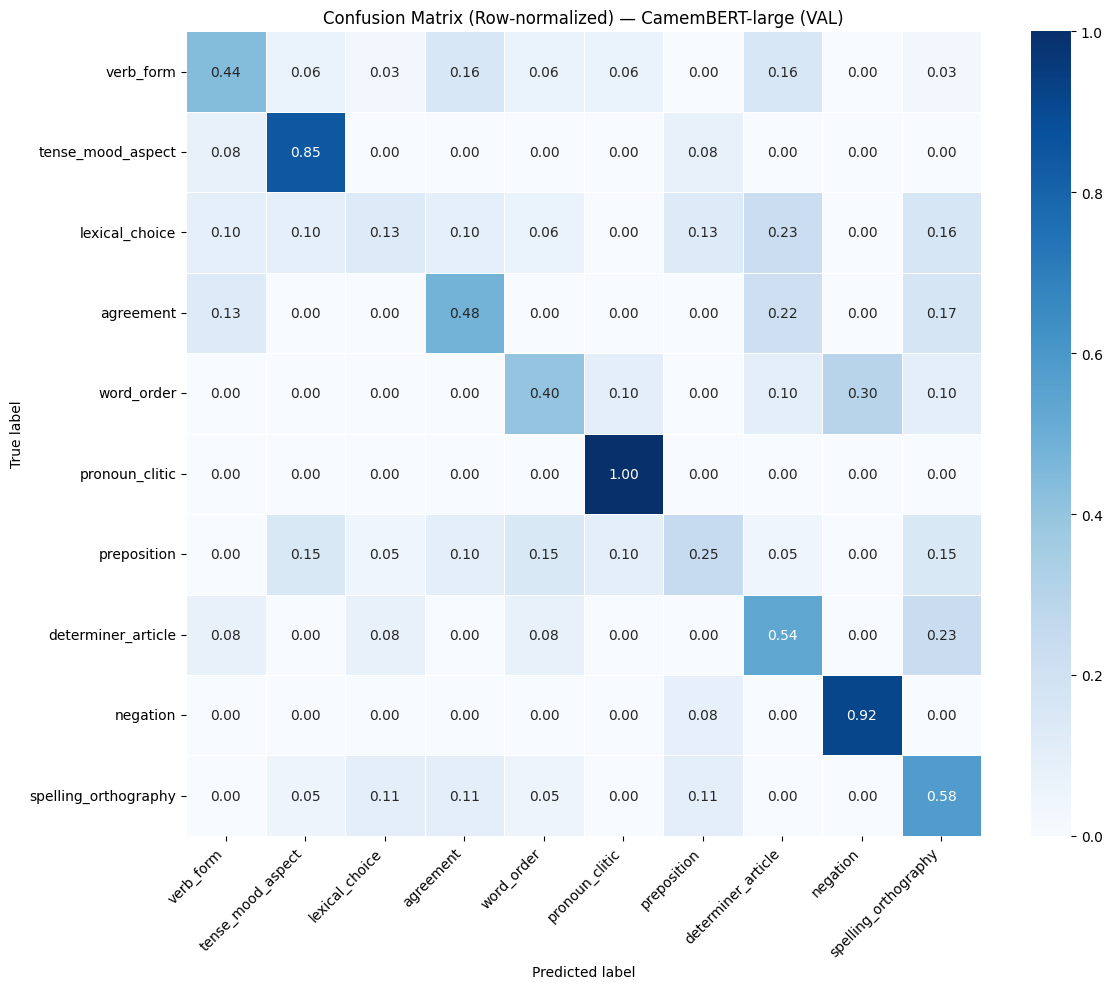

In [ ]:

#  load saved model and run on gold_val

BASE_DIR  = Path("/content/drive/MyDrive/Final_Project/data/final_splits_clean")
MODEL_DIR = "/content/drive/MyDrive/Final_Project/models/camembert_large_best"
OUTPUT_DIR = Path("/content/drive/MyDrive/Final_Project/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#Load validation set (gold)
val_df = pd.read_csv(BASE_DIR / "gold_val_clean.csv")
val_df["labels"] = val_df["label"].map(label2id)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)

# tokenizer/ model
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

# Tokenize
def tokenize_batch(batch):
    return tokenizer(batch["learner_sentence"], truncation=True, max_length=128)

val_ds = val_ds.map(tokenize_batch, batched=True)
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Predict (no training args needed)
eval_trainer = Trainer(model=model, data_collator=data_collator)
preds = eval_trainer.predict(val_ds)

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

# Report
print("\n===== CLASSIFICATION REPORT (VAL) =====\n")
print(classification_report(y_true, y_pred, target_names=LABELS, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=True,
    linewidths=0.5
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Row-normalized) — CamemBERT-large (VAL)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
save_path = OUTPUT_DIR / "cm_camembert_large_val.png"
plt.show()

### Results Transformer Experiment 4: CamemBERT-Large (MIXED SYN+REAL)

In this experiment, we replaced **CamemBERT-base** with **CamemBERT-large**, keeping the training setup identical (LR=2e-5, 3 epochs, same mixed data)

**Results (validation):**

* **Macro-F1:** 0.489 → **0.499**
* **Accuracy:** 0.464 → **0.481**

The larger model yields a small but consistent improvement (+1 macro-F1 point). Gains are mainly observed in structurally complex categories such as `verb_form` and `determiner_article`, while strongly performing categories (`negation`, `pronoun_clitic`, `tense_mood_aspect`) remain stable.

However, persistent confusions between `lexical_choice`, `preposition`, and `word_order` remain largely unchanged, suggesting that these errors are driven more by label overlap and task ambiguity than model capacity.

Overall, CamemBERT-large provides a modest but real improvement over the base model, without fundamentally changing the error profile.


## Experiment 5: Intermediate Supervised Fine-Tuning on the French Lang-8 Dataset

At this stage, model performance appears to have plateaued around a macro-F1 of ~0.50 using CamemBERT-large trained directly on the 10-class error taxonomy. Incremental architectural and optimization adjustments (class weighting, learning rate tuning, label smoothing, oversampling) did not yield substantial improvements.

In this experiment, I therefore explore intermediate supervised fine-tuning using the French subset of the Lang-8 dataset. This dataset provides human-annotated learner sentences paired with their corrected versions.

The objective of this intermediate stage is not to predict the final 10 error categories, but to train the encoder on a simpler auxiliary task:

* Original (learner) sentence → label 0 (incorrect)
* Corrected sentence → label 1 (correct)

By training a binary classifier on this task, the encoder is expected to become more sensitive to grammatical well-formedness and structural anomalies. The resulting checkpoint is then used to initialize the final 10-class error classification model.


In [ ]:

# Load Lang-8 binary CSVs

TRAIN_PATH = "/content/drive/MyDrive/Final_Project/data/intermediate_lang8_binary_v2/lang8_binary_train.csv"
VAL_PATH   = "/content/drive/MyDrive/Final_Project/data/intermediate_lang8_binary_v2/lang8_binary_val.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)

print("Lang-8 binary sizes:", train_df.shape, val_df.shape)
print(train_df["labels"].value_counts())
print(val_df["labels"].value_counts())

Lang-8 binary sizes: (154075, 2) (8109, 2)
labels
1    77052
0    77023
Name: count, dtype: int64
labels
0    4069
1    4040
Name: count, dtype: int64


In [ ]:

#  Clean helpers
_prefix_pattern = re.compile(r"^\s*\d+\s*[\.\-\)]\s*")
_ws = re.compile(r"\s+")

def clean_lang8_binary(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Ensure columns exist
    if "text" not in df.columns or "labels" not in df.columns:
        raise ValueError("Expected columns: 'text' and 'labels'")

    # Text to string + strip
    df["text"] = df["text"].astype(str).str.strip()

    # Remove "nan" literal + empty
    df = df[(df["text"].str.len() > 0) & (df["text"].str.lower() != "nan")].copy()

    # Remove numeric prefixes at start
    df["text"] = df["text"].apply(lambda x: re.sub(_prefix_pattern, "", x).strip())

    # Collapse whitespace
    df["text"] = df["text"].apply(lambda x: _ws.sub(" ", x).strip())

    # Drop again if empty after prefix removal
    df = df[df["text"].str.len() > 0].copy()

    # Labels to int
    df["labels"] = df["labels"].astype(int)

    # Remove too short / too long (loose guards)
    n_words = df["text"].apply(lambda x: len(x.split()))
    df = df[(n_words >= 3) & (n_words <= 80)].copy()

    # Deduplicate by normalized text
    df["k"] = df["text"].str.lower().str.strip()
    df = df.drop_duplicates(subset=["k"]).drop(columns=["k"]).reset_index(drop=True)

    return df


# Apply
print("Before clean:")
print("Train:", train_df.shape)
print(train_df["labels"].value_counts())
print("Val:", val_df.shape)
print(val_df["labels"].value_counts())

train_df = clean_lang8_binary(train_df)
val_df   = clean_lang8_binary(val_df)

print("\nAfter clean:")
print("Train:", train_df.shape)
print(train_df["labels"].value_counts())
print("Val:", val_df.shape)
print(val_df["labels"].value_counts())

Before clean:
Train: (154075, 2)
labels
1    77052
0    77023
Name: count, dtype: int64
Val: (8109, 2)
labels
0    4069
1    4040
Name: count, dtype: int64

After clean:
Train: (150422, 2)
labels
1    75617
0    74805
Name: count, dtype: int64
Val: (7934, 2)
labels
1    3969
0    3965
Name: count, dtype: int64


In [ ]:

# Load cleaned Lang-8 binary CSVs

TRAIN_PATH = "/content/drive/MyDrive/Final_Project/data/intermediate_lang8_binary_v2/lang8_binary_train.csv"
VAL_PATH   = "/content/drive/MyDrive/Final_Project/data/intermediate_lang8_binary_v2/lang8_binary_val.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)

# Ensure correct dtypes + remove NaN/empties just in case
def _final_clean(df):
    df = df.copy()
    df["text"] = df["text"].astype(str).str.strip()
    df = df[(df["text"].str.len() > 0) & (df["text"].str.lower() != "nan")].copy()
    df["labels"] = df["labels"].astype(int)
    return df.reset_index(drop=True)

train_df = _final_clean(train_df)
val_df   = _final_clean(val_df)

print("Train/Val sizes:", train_df.shape, val_df.shape)
print("Train label counts:", train_df["labels"].value_counts().to_dict())
print("Val label counts:", val_df["labels"].value_counts().to_dict())


# HF Dataset

hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
})

# Tokenizer/Model (CamemBERT-LARGE)

checkpoint = "almanach/camembert-large"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2,
    id2label={0: "learner", 1: "corrected"},
    label2id={"learner": 0, "corrected": 1},
)

def tokenize(batch):
    texts = [str(x) for x in batch["text"]]
    return tokenizer(texts, truncation=True, max_length=128)

tok_ds = hf_ds.map(tokenize, batched=True, remove_columns=[c for c in hf_ds["train"].column_names if c not in ["text","labels"]])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tok_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="binary")
    return {"accuracy": acc, "f1": f1}



# TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/lang8_binary_run_large_v2",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    num_train_epochs=2,
    learning_rate=2e-5,

    per_device_train_batch_size=8,   # large-friendly
    per_device_eval_batch_size=16,

    weight_decay=0.01,
    warmup_steps=0,
    max_grad_norm=1.0,
    seed=42,

    logging_strategy="steps",
    logging_steps=200,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
)


# Train

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

trainer.train()
metrics = trainer.evaluate()
print("Lang-8 binary eval:", metrics)



# Sanity-check predictions on VAL

preds = trainer.predict(tok_ds["validation"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print("y_true counts:", Counter(y_true))
print("y_pred counts:", Counter(y_pred))
print("confusion matrix:\n", confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))


# Save best

SAVE_DIR = "/content/drive/MyDrive/Final_Project/models/lang8_binary_best_large_v2"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved to:", SAVE_DIR)

Train/Val sizes: (154075, 2) (8109, 2)
Train label counts: {1: 77052, 0: 77023}
Val label counts: {0: 4069, 1: 4040}


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: almanach/camembert-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/154075 [00:00<?, ? examples/s]

Map:   0%|          | 0/8109 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Lang-8 binary eval: {'eval_loss': 0.4566473662853241, 'eval_accuracy': 0.794919225551856, 'eval_f1': 0.8073670798100313, 'eval_runtime': 29.6653, 'eval_samples_per_second': 273.349, 'eval_steps_per_second': 17.091, 'epoch': 2.0}
y_true counts: Counter({np.int64(0): 4069, np.int64(1): 4040})
y_pred counts: Counter({np.int64(1): 4593, np.int64(0): 3516})
confusion matrix:
 [[2961 1108]
 [ 555 3485]]
              precision    recall  f1-score   support

           0     0.8422    0.7277    0.7808      4069
           1     0.7588    0.8626    0.8074      4040

    accuracy                         0.7949      8109
   macro avg     0.8005    0.7952    0.7941      8109
weighted avg     0.8006    0.7949    0.7940      8109



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/Final_Project/models/lang8_binary_best_large_v2


In [ ]:

# Load your mixed 10-class data


train_df = pd.concat([train_syn, train_real], axis=0, ignore_index=True)
val_df   = gold_val.copy()
test_df  = gold_test.copy()

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

for df in [train_df, val_df, test_df]:
    df["labels"] = df["label"].map(label2id)

hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})



# INTERMEDIATE checkpoint

INTERMEDIATE_CKPT = "/content/drive/MyDrive/Final_Project/models/lang8_binary_best_large_v2"

tokenizer = AutoTokenizer.from_pretrained(INTERMEDIATE_CKPT)

model = AutoModelForSequenceClassification.from_pretrained(
    INTERMEDIATE_CKPT,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# new classification head is fresh
if hasattr(model, "classifier") and hasattr(model.classifier, "reset_parameters"):
    model.classifier.reset_parameters()
elif hasattr(model, "score") and hasattr(model.score, "reset_parameters"):
    model.score.reset_parameters()


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/Final_Project/models/lang8_binary_best_large_v2
Key                        | Status   |                                                                                        
---------------------------+----------+----------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 1024]) vs model:torch.Size([10, 1024])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([10])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:

# Tokenization

def tokenize(batch):
    return tokenizer(batch["learner_sentence"], truncation=True, max_length=128)

tok_ds = hf_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tok_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

# Training Arguments


training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Final_Project/models/camembert_large_intermediate_run",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    num_train_epochs=3,
    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    weight_decay=0.01,
    warmup_steps=0,
    max_grad_norm=1.0,
    seed=42,

    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()
metrics = trainer.evaluate()
print("10-class eval after intermediate:", metrics)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/Final_Project/models/lang8_binary_best_large_v2
Key                        | Status   |                                                                                        
---------------------------+----------+----------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 1024]) vs model:torch.Size([10, 1024])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([10])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Map:   0%|          | 0/14739 [00:00<?, ? examples/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

10-class eval after intermediate: {'eval_loss': 3.2324275970458984, 'eval_accuracy': 0.39344262295081966, 'eval_macro_f1': 0.4151542738005176, 'eval_runtime': 1.2233, 'eval_samples_per_second': 149.599, 'eval_steps_per_second': 9.81, 'epoch': 3.0}


In [ ]:

preds = trainer.predict(tok_ds["validation"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print("\n===== FINAL VAL METRICS =====")
print("Eval:", trainer.evaluate())

print("\n===== CLASSIFICATION REPORT (VAL) =====")
print(classification_report(y_true, y_pred, target_names=LABELS, digits=3))

print("\n===== CONFUSION MATRIX (VAL, counts) =====")
cm = confusion_matrix(y_true, y_pred)
print(cm)

print("\n===== CONFUSION MATRIX (VAL, row-normalized) =====")
cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(np.round(cm_norm, 3))


===== FINAL VAL METRICS =====


Eval: {'eval_loss': 3.2324275970458984, 'eval_accuracy': 0.39344262295081966, 'eval_macro_f1': 0.4151542738005176, 'eval_runtime': 1.2682, 'eval_samples_per_second': 144.303, 'eval_steps_per_second': 9.462, 'epoch': 3.0}

===== CLASSIFICATION REPORT (VAL) =====
                      precision    recall  f1-score   support

           verb_form      0.542     0.406     0.464        32
   tense_mood_aspect      0.857     0.462     0.600        13
      lexical_choice      0.400     0.065     0.111        31
           agreement      0.600     0.522     0.558        23
          word_order      0.273     0.300     0.286        10
      pronoun_clitic      0.476     1.000     0.645        10
         preposition      0.750     0.150     0.250        20
  determiner_article      0.136     0.231     0.171        13
            negation      0.889     0.667     0.762        12
spelling_orthography      0.200     0.632     0.304        19

            accuracy                          0.393   

In [ ]:
print("num_labels:", model.config.num_labels)
for name, p in model.named_parameters():
    if "classifier" in name or "score" in name:
        print(name, tuple(p.shape))

num_labels: 10
classifier.dense.weight (1024, 1024)
classifier.dense.bias (1024,)
classifier.out_proj.weight (10, 1024)
classifier.out_proj.bias (10,)


## Result experiment 5 : Intermediate supervised fine-tuning stage on the French Lang-8


### Conclusion

The intermediate supervised fine-tuning stage on the French Lang-8 dataset did not lead to an improvement over the best model obtained so far. After three epochs, the model achieved a **validation accuracy of 0.393** and a **macro-F1 of 0.415**, which remains substantially below the **0.499 macro-F1** reached by the previous **CamemBERT-large (mixed synthetic + real data)** experiment.

Although the auxiliary binary task was intended to make the encoder more sensitive to grammatical well-formedness, the resulting representation did not translate into improved performance on the downstream **10-class error classification** task. The confusion matrix indicates that several difficult categories—particularly `lexical_choice`, `preposition`, and `determiner_article`—remain poorly predicted, with `lexical_choice` showing especially low recall (0.065). In contrast, highly distinctive categories such as `pronoun_clitic` and `negation` remain relatively well captured.

This experiment suggests that **intermediate supervision based solely on sentence correctness is too coarse to transfer effectively to fine-grained error categorization**. While the encoder likely learns general grammatical sensitivity, this signal does not appear sufficiently aligned with the specific distinctions required by the 10-class taxonomy. Consequently, the approach does not outperform direct fine-tuning on the mixed synthetic and real error dataset used in Experiment 4.



## Experiment 6 : Error Analysis of Best Model (CamemBERT-large)

After extensive experimentation, model performance appears to have plateaued around a macro-F1 of ~0.50 on the validation set. Multiple optimization strategies were systematically evaluated:

* Class-weighted loss
* Learning rate reduction (1e-5)
* Label smoothing
* Oversampling of REAL data
* Larger architecture (CamemBERT-large)
* Intermediate supervised fine-tuning using a French Lang-8 corpus

These ablation experiments suggest that performance limitations are unlikely to stem from simple optimization issues.

The transition from CamemBERT-base to CamemBERT-large yielded only a modest but consistent improvement, mainly benefiting structurally clearer categories (e.g., tense_mood_aspect, negation, pronoun_clitic). This indicates that model capacity alone is not the primary bottleneck.

Similarly, intermediate supervised fine-tuning on the Lang-8 corpus, designed to inject additional grammatical sensitivity into the encoder, did not result in an significant improvement in the final 10-class classification task. This indicates that the issue is not merely a lack of grammatical pretraining.

Given these findings, the remaining hypothesis is that the performance ceiling is driven by the structure of the label taxonomy itself. Persistent confusion patterns across multiple experimental settings indicate potential intrinsic overlap or ambiguity between certain error categories.

To investigate this hypothesis,I now conduct a qualitative error analysis of the best-performing model (CamemBERT-large). Specifically, I:

* Examine the confusion matrix to identify dominant misclassification patterns
* Extract representative misclassified examples
* Analyze whether confusions arise from model weakness or from inherent label ambiguity
* Assess whether certain categories may benefit from a principled coarse-grained merging

The goal is not to artificially inflate performance, but to evaluate whether the current fine-grained taxonomy is optimally aligned with the empirical separability of the data.

If systematic overlap is confirmed, I will propose a linguistically justified restructuring of the taxonomy and evaluate the resulting performance under a reduced label space.

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

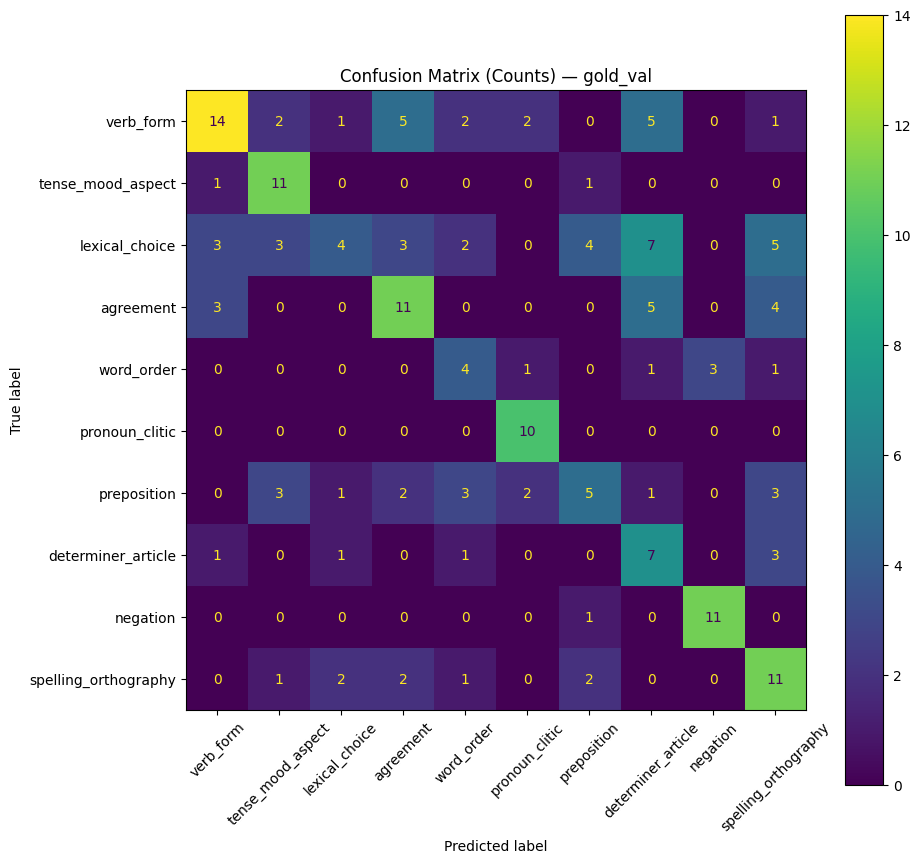

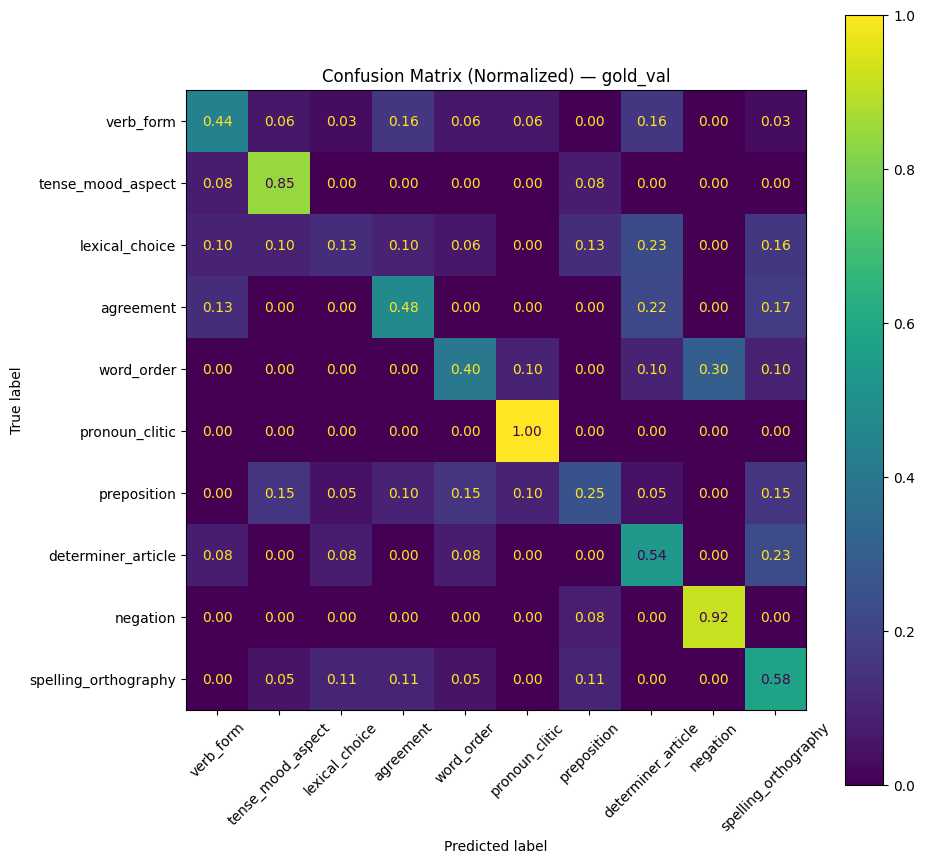

In [ ]:

#compute confusion matrix from saved best model

BASE_DIR  = Path("/content/drive/MyDrive/Final_Project/data/final_splits_clean")
MODEL_DIR = "/content/drive/MyDrive/Final_Project/models/camembert_large_best"

# Load validation set
val_df = pd.read_csv(BASE_DIR / "gold_val_clean.csv")
val_df["labels"] = val_df["label"].map(label2id)

val_ds = Dataset.from_pandas(val_df, preserve_index=False)

# Load model
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

def tokenize_batch(batch):
    return tokenizer(batch["learner_sentence"], truncation=True, max_length=128)

val_ds = val_ds.map(tokenize_batch, batched=True)
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
eval_trainer = Trainer(model=model, data_collator=data_collator)

preds = eval_trainer.predict(val_ds)

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Display confusion matrix (counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (Counts) — gold_val")
plt.show()

# Display confusion matrix (normalized)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 10))
disp_norm.plot(ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Confusion Matrix (Normalized) — gold_val")
plt.show()

In [ ]:


# Copy to avoid modifying original
cm_copy = cm_norm.copy()

# Remove diagonal
np.fill_diagonal(cm_copy, 0)

# Flatten and get top indices
flat_indices = np.argsort(cm_copy.ravel())[::-1]

top_k = 5
print("Top confusion pairs (row-normalized):\n")

count = 0
for idx in flat_indices:
    if count >= top_k:
        break
    i, j = np.unravel_index(idx, cm_copy.shape)
    value = cm_copy[i, j]
    if value > 0:
        print(f"True: {LABELS[i]}  →  Pred: {LABELS[j]}  |  Proportion: {value:.3f}")
        count += 1

Top confusion pairs (row-normalized):

True: word_order  →  Pred: negation  |  Proportion: 0.300
True: determiner_article  →  Pred: spelling_orthography  |  Proportion: 0.231
True: lexical_choice  →  Pred: determiner_article  |  Proportion: 0.226
True: agreement  →  Pred: determiner_article  |  Proportion: 0.217
True: agreement  →  Pred: spelling_orthography  |  Proportion: 0.174


In [ ]:


BASE_DIR  = Path("/content/drive/MyDrive/Final_Project/data/final_splits_clean")
MODEL_DIR = "/content/drive/MyDrive/Final_Project/models/camembert_large_best"

TOP_CONFUSIONS = 5   # number of confusion pairs to analyze
K = 3                # examples per pair


# validation set

val_df = pd.read_csv(BASE_DIR / "gold_val_clean.csv")
val_df["labels"] = val_df["label"].map(label2id)

val_ds = Dataset.from_pandas(val_df, preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

def tokenize(batch):
    return tokenizer(batch["learner_sentence"], truncation=True, max_length=128)

val_ds = val_ds.map(tokenize, batched=True)
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(model=model, data_collator=data_collator)


#  Predict

preds = trainer.predict(val_ds)

y_true = preds.label_ids
logits = preds.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = probs.argmax(axis=1)


# Compute confusion matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Remove diagonal
cm_copy = cm_norm.copy()
np.fill_diagonal(cm_copy, 0)

# top confusion pairs
flat_idx = np.argsort(cm_copy.ravel())[::-1]

pairs = []
for idx_flat in flat_idx:
    i, j = np.unravel_index(idx_flat, cm_copy.shape)
    if cm_copy[i, j] > 0:
        pairs.append((i, j, cm_copy[i, j]))
    if len(pairs) == TOP_CONFUSIONS:
        break

print("\n===== TOP CONFUSION PAIRS =====\n")
for i, j, v in pairs:
    print(f"{LABELS[i]}  →  {LABELS[j]}  |  Proportion: {v:.3f}")


#  examples for each pair

print("\n===== EXAMPLES =====\n")

for i, j, v in pairs:
    true_label = LABELS[i]
    pred_label = LABELS[j]
    true_id = i
    pred_id = j

    mask = (y_true == true_id) & (y_pred == pred_id)
    idxs = np.where(mask)[0]

    if len(idxs) == 0:
        continue

    conf_scores = probs[idxs, pred_id]
    order = np.argsort(-conf_scores)
    idxs = idxs[order][:K]

    print(f"\n--- TRUE: {true_label} → PRED: {pred_label} ---\n")

    for idx in idxs:
        print(f"Text: {val_df.loc[idx, 'learner_sentence']}")
        print(f"Pred prob: {probs[idx, pred_id]:.3f}")
        print("-" * 80)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]


===== TOP CONFUSION PAIRS =====

word_order  →  negation  |  Proportion: 0.300
determiner_article  →  spelling_orthography  |  Proportion: 0.231
lexical_choice  →  determiner_article  |  Proportion: 0.226
agreement  →  determiner_article  |  Proportion: 0.217
agreement  →  spelling_orthography  |  Proportion: 0.174

===== EXAMPLES =====


--- TRUE: word_order → PRED: negation ---

Text: Je ne pense seulement pas à la réussite mais aussi à l’échec possible.
Pred prob: 1.000
--------------------------------------------------------------------------------
Text: Il y a quelque choses j'ai connatitré pas avant je suis venu ici.
Pred prob: 0.999
--------------------------------------------------------------------------------
Text: 22. Je ne sais pas une raison vraie de son absence.
Pred prob: 0.766
--------------------------------------------------------------------------------

--- TRUE: determiner_article → PRED: spelling_orthography ---

Text: Je suis allee prendre le bain public dans ce


## RESULTS: Error Analysis of the Best Model (CamemBERT-large)

The most frequent confusions observed in the row-normalized confusion matrix are:

| True label         | Predicted label      | Proportion |
| ------------------ | -------------------- | ---------- |
| word_order         | negation             | 0.30       |
| determiner_article | spelling_orthography | 0.23       |
| lexical_choice     | determiner_article   | 0.23       |
| agreement          | determiner_article   | 0.22       |
| agreement          | spelling_orthography | 0.17       |

Representative examples illustrate these patterns.

### word_order / lexical_choice / preposition confusions

* *Je ne pense seulement pas à la réussite…*
* *Il y a quelque choses… pas avant je suis venu ici.*

These errors illustrate how **word order errors often interact with lexical selection or function-word placement**. In learner language, incorrect ordering frequently results from choosing an inappropriate construction or placing a function word in the wrong syntactic position.

From the model’s perspective, these cases often appear as **local selection errors**, since the surface signal is typically a misplaced function word, particle, or preposition. This makes it difficult for the classifier to distinguish between structural ordering mistakes and lexical selection issues.

### agreement / determiner_article confusions

* *Ma spécialité est les sciences politiques*
* *Je suis content pour études commence*

These errors occur within **noun phrase morphosyntax**, where determiner choice and agreement features interact. In short learner sentences, the model often cannot reliably determine whether the error stems from incorrect agreement, determiner selection, or both simultaneously.

### lexical_choice / determiner_article confusions

* *au sujet de un garçon*
* *aucun doute monétaire*

In these examples, the visible error may occur on a determiner or function word, although the underlying issue relates to **lexical selection within a construction**.

---

# Label Merging Strategy

Based on this analysis, two merges are introduced to reduce systematic ambiguity in the label space.

## Merge A

agreement + determiner_article → **morpho_syntax**

These two labels frequently overlap because determiner choice and agreement features are closely tied within the noun phrase. In many learner sentences, both errors appear simultaneously or are difficult to separate reliably.

Example (true agreement but predicted determiner/article):

* *Ma spécialité est les sciences politiques…*

Here the error can be interpreted either as a number/determiner mismatch or as an agreement problem, illustrating the structural overlap between the two categories.

---

## Merge B

lexical_choice + preposition + word_order → **lexico_choice**

Error analysis revealed that **lexical_choice, preposition, and word_order form a second cluster of systematic confusions**. In many learner sentences, these errors manifest as incorrect selection or placement of a word within a short syntactic context.

For the classifier, these cases often appear as **local selection errors**, where the incorrect element could plausibly be interpreted as a lexical choice error, a preposition error, or a word order issue.

Example:

* *Le principal motif de l'acte ne fait aucun doute monétaire.*

Although the error relates to lexical usage, similar cases often involve incorrect prepositions or misplaced function words within a construction.

Merging these categories therefore reflects the fact that they frequently arise from the same underlying phenomenon: **incorrect lexical or functional word selection within a construction**.

---

# Revised Label Set

The resulting taxonomy becomes:

* verb_form
* tense_mood_aspect
* morpho_syntax
* lexico_choice
* pronoun_clitic
* negation
* spelling_orthography

This simplified label space reduces systematic ambiguity between overlapping categories and leads to a more stable classification task for the model.



In [ ]:

# Original labels order (must match your existing taxonomy)
LABELS_10 = [
    "verb_form",
    "tense_mood_aspect",
    "lexical_choice",
    "agreement",
    "word_order",
    "pronoun_clitic",
    "preposition",
    "determiner_article",
    "negation",
    "spelling_orthography"
]



# Merge A:
# agreement + determiner_article -> morpho_syntax
# Merge B:
# lexical_choice + preposition + word_order -> lexico_choice

def merge_label_10_to_7(lbl: str) -> str:
    if lbl in ["agreement", "determiner_article"]:
        return "morpho_syntax"
    if lbl in ["lexical_choice", "preposition", "word_order"]:
        return "lexico_choice"
    return lbl

LABELS_7 = [
    "verb_form",
    "tense_mood_aspect",
    "lexico_choice",          # merged (lexical_choice+preposition+word_order)
    "morpho_syntax",          # merged (agreement+determiner_article)
    "pronoun_clitic",
    "negation",
    "spelling_orthography",
]

label2id_7 = {l:i for i,l in enumerate(LABELS_7)}
id2label_7 = {i:l for l,i in label2id_7.items()}

def apply_merge(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["label_merged"] = df["label"].apply(merge_label_10_to_7)
    df["labels"] = df["label_merged"].map(label2id_7).astype(int)
    return df

train_syn_m  = apply_merge(train_syn)
train_real_m = apply_merge(train_real)
val_m        = apply_merge(gold_val)
test_m       = apply_merge(gold_test)

# mixed train
train_m = pd.concat([train_syn_m, train_real_m], axis=0, ignore_index=True)

print("==== SIZES (after merge) ====")
print("Train:", train_m.shape, " Val:", val_m.shape, " Test:", test_m.shape)

print("\n==== LABEL COUNTS (Train, merged) ====")
print(train_m["label_merged"].value_counts())

print("\n==== LABEL COUNTS (Val, merged) ====")
print(val_m["label_merged"].value_counts())

==== SIZES (after merge) ====
Train: (14739, 4)  Val: (183, 4)  Test: (276, 4)

==== LABEL COUNTS (Train, merged) ====
label_merged
lexico_choice           4579
morpho_syntax           2745
verb_form               1911
tense_mood_aspect       1697
pronoun_clitic          1459
negation                1246
spelling_orthography    1102
Name: count, dtype: int64

==== LABEL COUNTS (Val, merged) ====
label_merged
lexico_choice           61
morpho_syntax           36
verb_form               32
spelling_orthography    19
tense_mood_aspect       13
negation                12
pronoun_clitic          10
Name: count, dtype: int64


In [ ]:

# HF DATASETS

hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_m[["learner_sentence", "labels"]], preserve_index=False),
    "validation": Dataset.from_pandas(val_m[["learner_sentence", "labels"]], preserve_index=False),
    "test": Dataset.from_pandas(test_m[["learner_sentence", "labels"]], preserve_index=False),
})


# TOKENIZER and MODEL (CamemBERT-large)


checkpoint = "almanach/camembert-large"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(LABELS_7),
    id2label=id2label_7,
    label2id=label2id_7
)

def tokenize(batch):
    return tokenizer(batch["learner_sentence"], truncation=True, max_length=128)

tok_ds = hf_ds.map(tokenize, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tok_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


# METRICS


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/809k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: almanach/camembert-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/14739 [00:00<?, ? examples/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.242199,2.576016,0.513661,0.564920
2,0.089217,2.945213,0.546448,0.568641
3,0.038262,2.639368,0.568306,0.605981


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


===== MERGED-7 VAL METRICS =====
{'eval_loss': 2.6393682956695557, 'eval_accuracy': 0.5683060109289617, 'eval_macro_f1': 0.6059808154335009, 'eval_runtime': 0.6072, 'eval_samples_per_second': 301.381, 'eval_steps_per_second': 19.763, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved best merged-7 model to: /content/drive/MyDrive/Final_Project/models/camembert_large_merged7_best

===== CLASSIFICATION REPORT (VAL) =====

                      precision    recall  f1-score   support

           verb_form      0.579     0.344     0.431        32
   tense_mood_aspect      0.667     0.462     0.545        13
       lexico_choice      0.594     0.623     0.608        61
       morpho_syntax      0.500     0.583     0.538        36
      pronoun_clitic      0.833     1.000     0.909        10
            negation      0.900     0.750     0.818        12
spelling_orthography      0.333     0.474     0.391        19

            accuracy                          0.568       183
           macro avg      0.629     0.605     0.606       183
        weighted avg      0.584     0.568     0.567       183


===== CONFUSION MATRIX (VAL, counts) =====

[[11  1  7  8  2  0  3]
 [ 2  6  5  0  0  0  0]
 [ 1  1 38  9  0  1 11]
 [ 4  0  7 21  0  0  4]
 [ 0  0  0  0 10  0  0]
 [ 0

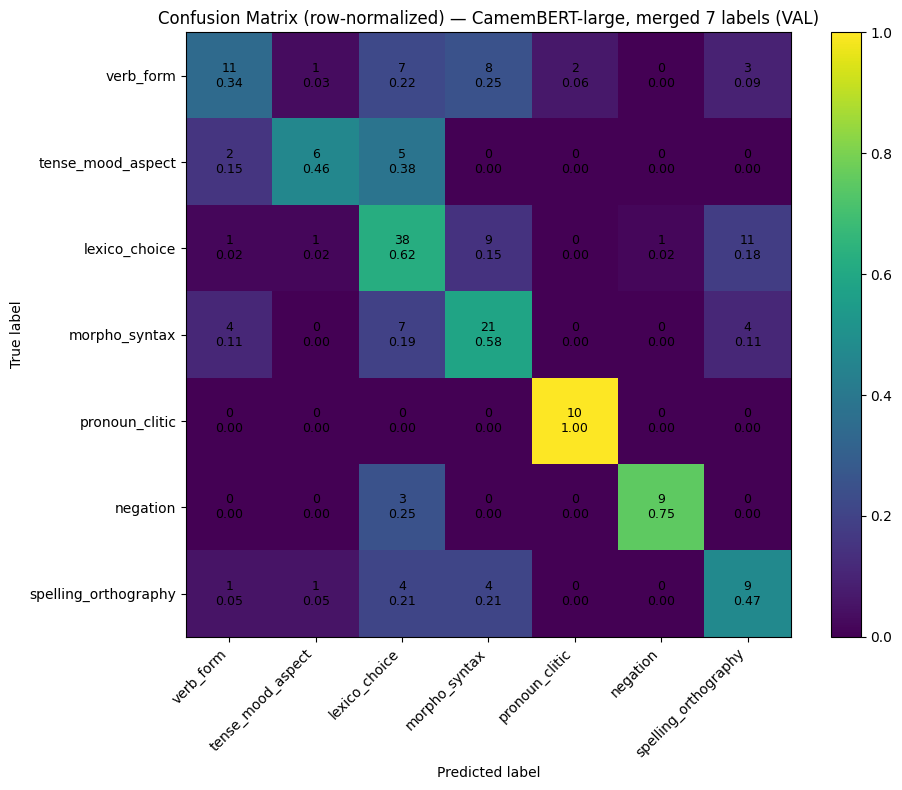

In [ ]:


# TRAINING ARGS

OUT_DIR = "/content/drive/MyDrive/Final_Project/models/camembert_large_merged7_run1"
BEST_DIR = "/content/drive/MyDrive/Final_Project/models/camembert_large_merged7_best"

training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    weight_decay=0.01,
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    seed=42,

    logging_dir="logs",
    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=2,

    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

#  Tain, eval, save


trainer.train()
val_metrics = trainer.evaluate()
print("\n===== MERGED-7 VAL METRICS =====")
print(val_metrics)

trainer.save_model(BEST_DIR)
tokenizer.save_pretrained(BEST_DIR)
print("\nSaved best merged-7 model to:", BEST_DIR)


# cm


preds = trainer.predict(tok_ds["validation"])
y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

print("\n===== CLASSIFICATION REPORT (VAL) =====\n")
print(classification_report(y_true, y_pred, target_names=LABELS_7, digits=3))

cm = confusion_matrix(y_true, y_pred)

print("\n===== CONFUSION MATRIX (VAL, counts) =====\n")
print(cm)


cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Plot with numbers
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm)

ax.set_xticks(np.arange(len(LABELS_7)))
ax.set_yticks(np.arange(len(LABELS_7)))
ax.set_xticklabels(LABELS_7, rotation=45, ha="right")
ax.set_yticklabels(LABELS_7)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (row-normalized) — CamemBERT-large, merged 7 labels (VAL)")

# annotate with normalized values + counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i,
            f"{cm[i,j]}\n{cm_norm[i,j]:.2f}",
            ha="center", va="center",
            fontsize=9
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Result experiments 6 : Error Analysis and label merged.

## Key Insights from Error Analysis

The error analysis revealed that the main limitation of the model did not stem from model capacity or optimization choices. Multiple experiments were conducted, including learning rate tuning, class-weighted loss, label smoothing, oversampling, scaling from CamemBERT-base to CamemBERT-large, and intermediate supervised fine-tuning using the Lang-8 dataset. None of these approaches produced substantial improvements.

Inspection of the confusion matrix and qualitative examples instead showed that many errors arose from systematic ambiguity between closely related linguistic categories, particularly between agreement and determiner/article, as well as between lexical choice and preposition. In learner language, these error types often co-occur within the same sentence span, making them difficult to distinguish reliably even for human annotators.

Based on these observations, the label taxonomy was refined by merging these ambiguous categories into broader linguistically coherent classes (morpho_syntax and lexico_choice). This modification significantly reduced label ambiguity and improved the macro-F1 score from ≈0.50 to ≈0.61, confirming that part of the difficulty of the task originated from the granularity of the original taxonomy rather than from model limitations.

To evaluate the final performance of the system, I use the model trained with the **refined label taxonomy**, which merges the previously ambiguous categories into the broader classes *morpho_syntax* and *lexico_choice*. As this configuration produced the best validation results (macro-F1 ≈ 0.61), it is selected as the **final model** for evaluation on the test set. The following section reports its performance on unseen data.


Casting the dataset:   0%|          | 0/276 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Map:   0%|          | 0/276 [00:00<?, ? examples/s]

===== MERGED-7 TEST METRICS =====
{'test_accuracy': 0.5833333333333334, 'test_macro_f1': 0.6163076540452662}

===== CLASSIFICATION REPORT (TEST) =====

                      precision    recall  f1-score   support

           verb_form      0.667     0.426     0.519        47
   tense_mood_aspect      0.500     0.389     0.438        18
       lexico_choice      0.571     0.629     0.599        89
       morpho_syntax      0.565     0.556     0.560        63
      pronoun_clitic      1.000     0.706     0.828        17
            negation      0.800     0.923     0.857        13
spelling_orthography      0.422     0.655     0.514        29

            accuracy                          0.583       276
           macro avg      0.646     0.612     0.616       276
        weighted avg      0.603     0.583     0.583       276



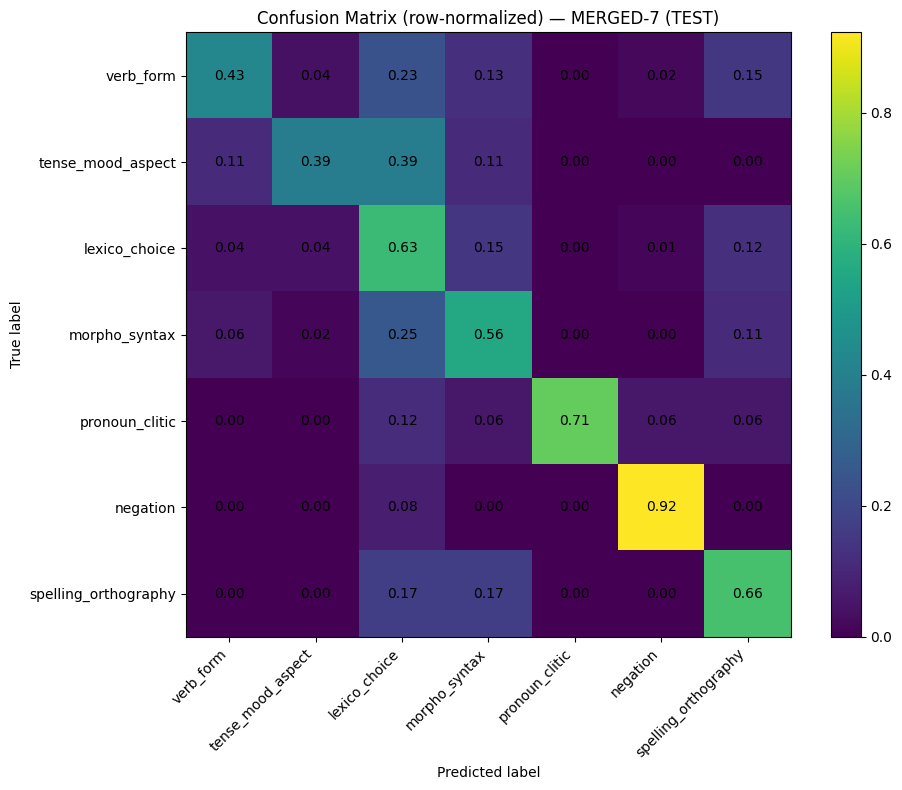

In [ ]:


MODEL_DIR = "/content/drive/MyDrive/Final_Project/models/camembert_large_merged7_best"

LABELS_7 = [
    "verb_form",
    "tense_mood_aspect",
    "lexico_choice",
    "morpho_syntax",
    "pronoun_clitic",
    "negation",
    "spelling_orthography",
]
label2id_7 = {l:i for i,l in enumerate(LABELS_7)}
id2label_7 = {i:l for l,i in label2id_7.items()}


#  TEST DATA (use existing test_m)

req_cols = ["learner_sentence", "labels"]
for c in req_cols:
    if c not in test_m.columns:
        raise ValueError(f"test_m must contain column '{c}', but columns are: {list(test_m.columns)}")

test_df = test_m.copy()
test_df["learner_sentence"] = test_df["learner_sentence"].astype(str)
test_df["labels"] = test_df["labels"].astype("int64")

# Build HF Dataset
features = Features({
    "learner_sentence": Value("string"),
    "labels": Value("int64"),
})
test_ds = Dataset.from_pandas(test_df[["learner_sentence", "labels"]], preserve_index=False).cast(features)


# LOAD MODEL/TOKENIZER

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    num_labels=len(LABELS_7),
    id2label=id2label_7,
    label2id=label2id_7,
)

def tokenize(batch):
    return tokenizer(batch["learner_sentence"], truncation=True, max_length=128)

test_ds = test_ds.map(tokenize, batched=True)


# Data collator

base_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def collate_with_long_labels(features):
    batch = base_collator(features)
    if "labels" in batch:
        batch["labels"] = batch["labels"].long()
    return batch

test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

trainer = Trainer(
    model=model,
    data_collator=collate_with_long_labels,
)


# Predict

preds = trainer.predict(test_ds)

y_true = preds.label_ids.astype(int)
logits = preds.predictions
y_pred = np.argmax(logits, axis=1)

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("===== MERGED-7 TEST METRICS =====")
print({"test_accuracy": acc, "test_macro_f1": macro_f1})

print("\n===== CLASSIFICATION REPORT (TEST) =====\n")
print(classification_report(y_true, y_pred, target_names=LABELS_7, digits=3))


# cm

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, interpolation="nearest")
ax.set_title("Confusion Matrix (row-normalized) — MERGED-7 (TEST)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(np.arange(len(LABELS_7)))
ax.set_yticks(np.arange(len(LABELS_7)))
ax.set_xticklabels(LABELS_7, rotation=45, ha="right")
ax.set_yticklabels(LABELS_7)

# Annotate cells with values
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Final Results on Test Set

The final model was evaluated on the held-out test set after refining the original 10-class taxonomy into a 7-class taxonomy through linguistically motivated merges.

The following merges were applied based on the error analysis:

* **agreement + determiner_article → morpho_syntax**
* **lexical_choice + preposition + word_order → lexico_choice**

These merges were motivated by systematic confusions observed in the confusion matrix and qualitative inspection of prediction errors, where these categories frequently overlapped within the same learner sentences.

The final CamemBERT-large model achieved the following performance on the test set:

* **Accuracy:** 0.583
* **Macro-F1:** 0.616

This represents a substantial improvement compared to the best performance obtained with the original 10-class taxonomy (**macro-F1 ≈ 0.499**), suggesting that part of the difficulty of the task originated from the granularity and overlap of the annotation scheme rather than from model capacity.

---

# Final Discussion

This project explored several approaches to improve automatic classification of learner language errors in French. Multiple optimization strategies were tested, including learning rate tuning, weighted loss, label smoothing, oversampling, model scaling from CamemBERT-base to CamemBERT-large, and intermediate supervised training using the Lang-8 dataset.

However, these experiments showed that model capacity and optimization were not the main limiting factors. Instead, error analysis revealed that several categories in the original taxonomy were systematically confusable, particularly lexical_choice, preposition, word_order, agreement, and determiner_article.

By merging the most ambiguous categories into linguistically coherent groups (morpho_syntax and lexico_choice), the task became more consistent with the patterns the model could reliably learn. This refinement significantly improved the macro-F1 score from approximately **0.50 to 0.62**.

Given the extensive set of experiments already conducted, these results likely represent the final performance of the current system. The findings suggest that, for learner error classification tasks, careful design of the label taxonomy can be as important as model architecture and training strategy.
